<div style="
    text-align: center;
    max-width: 600px;
    margin: 0 auto;
    background:
    rgb(234, 62, 131);
    color: white;
    padding: 12px;
    border-radius: 4px;
">
  <h3> ★ sample routes generation ★ </h3>
  <p> The code in this notebook finds and plots a set of paths from origin to destination based on varying weight adjustment functions.</p>
</div>

In [44]:
import osmnx as ox
import numpy as np
import geopandas as gpd
import pandas as pd
import folium
import warnings
from shapely import wkt
warnings.filterwarnings("ignore")
import math
import networkx as nx
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import ast
import json
from folium.plugins import HeatMap

<div style="
    text-align: center;
    max-width: 600px;
    margin: 0 auto;
    background:
    rgb(234, 62, 131);
    color: white;
    padding: 12px;
    border-radius: 4px;
">
  <h3> ★ can modify ★ </h3>
  <p> 1. Change {curr_score} to be the name of the column holding your scores.</p>
  <p> 2. routes_df holds origin/destination pairs (lat, lon format).</p>
  <p> 3. adjusted_edges holds edges with scores per edge.</p>
  <p> 4. north, east, sout, west define the boundary box. </p>
  <p> 5. Note: appeal score is 1 as a placeholder.</p>
</div>

In [45]:
routes_df = pd.read_csv('../data/routes.csv')


In [53]:
test = 1005
al = 1
be = 0.05

crime_night = pd.read_csv('../../crime_density/data/nighttime_crimes_alltypes_weighted.csv')
adjusted_edges = pd.read_csv(f'../edges_{test}.csv')
north, east, south, west = 47.62425802431359, -122.35919327219091, 47.596252480947555, -122.31765250756945
fxn_names=['inverse', 'inverse_log', 'inverse_log_nat', 'inverse_sqrt', 'inverse_sqr', 'inverse_exp', 'linear1', 'linear1p4', 'linear10', 'shortest']
fxn_equations = [
    "f₁(x) = 1/x",
    "f₂(x) = 1/log(x+1)",
    "f₃(x) = 1/ln(x+1)",
    "f₄(x) = 1/√x",
    "f₅(x) = 1/(x^2)",
    "f₆(x) = 1/(2^x)",
    "f₇(x) = 1 - x",
    "f₈(x) = 1.4 - x",
    "f₉(x) = 10 - x",
    "shortest path"
]
fxn_order = {name: i for i, name in enumerate(fxn_names)}
num_fxns = len(fxn_names)

colors = [
        'orangered', 'dodgerblue', 'darkorange', 'darkviolet', 'forestgreen',
        'magenta', 'black', 'sienna', 'lightseagreen', 'mediumblue'
    ]

color_nns = [
        'Red', 'Blue', 'Orange', 'Purple', 'Green',
        'Pink', 'Black', 'Brown', 'Turquoise', 'Dark Blue']

app_score = 'AI_avg_appeal_score'
saf_score = 'ai_density_night_average'
acc_score = 'ai_access_average'

<div style="
    text-align: center;
    max-width: 600px;
    margin: 0 auto;
    background:
    rgb(234, 62, 131);
    color: white;
    padding: 12px;
    border-radius: 4px;
">
  <h3> ★ do not modify ★ </h3>
</div>

In [54]:
def assign_user_weight(df, wts: dict, isday):
    if isday:
        df['weighted_score'] = df['access_score'] * wts['access_score'] + df['safety_score_day_density'] * wts['safety_score_day'] + df['appeal_score'] * wts['appeal_score']
        return df
    df['weighted_score'] = df[acc_score] * wts['access_score'] + df[saf_score] * wts['safety_score_night'] + df[app_score] * wts['appeal_score']
    return df

<div style="
    text-align: center;
    max-width: 600px;
    margin: 0 auto;
    background:
    rgb(234, 62, 131);
    color: white;
    padding: 12px;
    border-radius: 4px;
">
  <h3> ★ can modify ★ </h3>
  <p>1. Define score/column weights in the first cell.</p>
  <p> 2. Define columns for each function weight in the second cell - also fill out fxn_cols and fxn_names accordingly (lengths must match).</p>
</div>

In [55]:
adjusted_edges = assign_user_weight(adjusted_edges, {'access_score' : 0.33, 'safety_score_night': 0.33, 'appeal_score': 0.33}, False)

In [56]:
adjusted_edges['inverse'] = adjusted_edges['weighted_score'].apply(lambda x: 1 / x if x != 0 else 1.0)
adjusted_edges['inverse_log'] = adjusted_edges['weighted_score'].apply(lambda x: 1 / np.log(x+1) if x!= 0 else 1.0)
adjusted_edges['inverse_log_nat'] = adjusted_edges['weighted_score'].apply(lambda x: 1 / math.log(x+1, math.e) if x > 0 else 1.0)
adjusted_edges['inverse_sqrt'] = adjusted_edges['weighted_score'].apply(lambda x: 1 / np.sqrt(x) if x != 0 else 1.0)
adjusted_edges['inverse_sqr'] = adjusted_edges['weighted_score'].apply(lambda x: 1 / x**2 if x != 0 else 1.0)
adjusted_edges['inverse_exp'] = adjusted_edges['weighted_score'].apply(lambda x: 1 / 2 **x if x != 0 else 1.0)

adjusted_edges['linear1'] = 1 - adjusted_edges['weighted_score']
adjusted_edges['linear1p4'] = 1.4 - adjusted_edges['weighted_score']
adjusted_edges['linear10'] = 10 - adjusted_edges['weighted_score']


# T value where 1 = good
adjusted_edges['slope_score_u_v'] = 1 - adjusted_edges['slope_cost_u_v']
adjusted_edges['slope_score_v_u'] = 1 - adjusted_edges['slope_cost_v_u']


# Inverse functions applied to T value
adjusted_edges['linear1_cost_u_v'] = 1 - adjusted_edges['slope_score_u_v']
adjusted_edges['linear1_cost_v_u'] = 1 - adjusted_edges['slope_score_v_u']

adjusted_edges['linear1p4_cost_u_v'] = 1.4 - adjusted_edges['slope_score_u_v']
adjusted_edges['linear1p4_cost_v_u'] = 1.4 - adjusted_edges['slope_score_v_u']

adjusted_edges['linear10_cost_u_v'] = 10 - adjusted_edges['slope_score_u_v']
adjusted_edges['linear10_cost_v_u'] = 10 - adjusted_edges['slope_score_v_u']

adjusted_edges['inverse_cost_u_v'] = adjusted_edges['slope_score_u_v'].apply(lambda x: 1 / x if x != 0 else 1.0)
adjusted_edges['inverse_cost_v_u'] = adjusted_edges['slope_score_v_u'].apply(lambda x: 1 / x if x != 0 else 1.0)

adjusted_edges['inverse_log_cost_u_v'] = adjusted_edges['slope_score_u_v'].apply(lambda x: 1 / np.log(x+1) if x!= 0 else 1.0)
adjusted_edges['inverse_log_cost_v_u'] = adjusted_edges['slope_score_v_u'].apply(lambda x: 1 / np.log(x+1) if x!= 0 else 1.0)

adjusted_edges['inverse_log_nat_cost_u_v'] = adjusted_edges['slope_score_u_v'].apply(lambda x: 1 / math.log(x+1, math.e) if x > 0 else 1.0)
adjusted_edges['inverse_log_nat_cost_v_u'] = adjusted_edges['slope_score_v_u'].apply(lambda x: 1 / math.log(x+1, math.e) if x > 0 else 1.0)

adjusted_edges['inverse_sqr_cost_u_v'] = adjusted_edges['slope_score_u_v'].apply(lambda x: 1 / x**2 if x != 0 else 1.0)
adjusted_edges['inverse_sqr_cost_v_u'] = adjusted_edges['slope_score_v_u'].apply(lambda x: 1 / x**2 if x != 0 else 1.0)

adjusted_edges['inverse_sqrt_cost_u_v'] = adjusted_edges['slope_score_u_v'].apply(lambda x: 1 / np.sqrt(x) if x != 0 else 1.0)
adjusted_edges['inverse_sqrt_cost_v_u'] = adjusted_edges['slope_score_v_u'].apply(lambda x: 1 / np.sqrt(x) if x != 0 else 1.0)

adjusted_edges['inverse_exp_cost_u_v'] = adjusted_edges['slope_score_u_v'].apply(lambda x: 1 / 2 **x if x != 0 else 1.0)
adjusted_edges['inverse_exp_cost_v_u'] = adjusted_edges['slope_score_v_u'].apply(lambda x: 1 / 2 **x if x != 0 else 1.0)

adjusted_edges['shortest'] = adjusted_edges['length']


count    18972.000000
mean         0.650588
std          0.096406
min          0.233678
25%          0.590743
50%          0.658449
75%          0.715743
max          0.905636
Name: weighted_score, dtype: float64


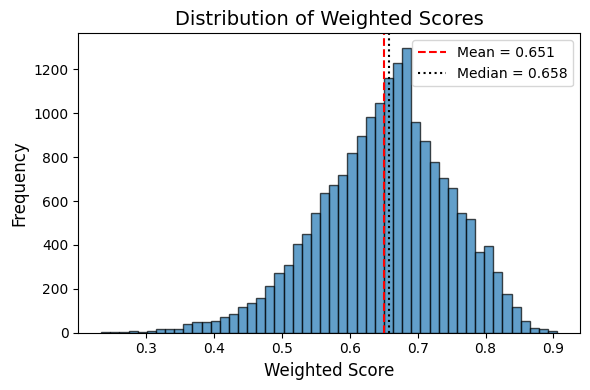

In [57]:
print(adjusted_edges['weighted_score'].describe())

plt.figure(figsize=(6,4))
plt.hist(adjusted_edges["weighted_score"], edgecolor = "black", bins=50, alpha=0.7)

plt.title("Distribution of Weighted Scores", fontsize=14)
plt.xlabel("Weighted Score", fontsize=12)
plt.ylabel("Frequency", fontsize=12)

# add vertical lines for mean, median
plt.axvline(adjusted_edges["weighted_score"].mean(), color="red", linestyle="--", label=f"Mean = {adjusted_edges['weighted_score'].mean():.3f}")
plt.axvline(adjusted_edges["weighted_score"].median(), color="black", linestyle=":", label=f"Median = {adjusted_edges['weighted_score'].median():.3f}")

plt.legend(fontsize=10)
plt.tight_layout()
plt.show()

In [58]:
print(adjusted_edges.columns)

Index(['Unnamed: 0.3', 'Unnamed: 0.2', 'Unnamed: 0.1', 'Unnamed: 0', 'u', 'v',
       'key', 'osm_id', 'highway', 'oneway', 'reversed', 'length', 'lanes',
       'maxspeed', 'name', 'access', 'service', 'geometry', 'bridge', 'tunnel',
       'ref', 'sidewalk_notes', 'access_score', 'slope_notes',
       'safety_score_day_buffer', 'safety_score_night_buffer',
       'safety_score_day_density', 'safety_score_night_density', 'travel_time',
       'AI_avg_appeal_score', 'AI_avg_safety_score',
       'AI_avg_accessibility_score', 'AI_avg_total_score', 'point_count',
       'ai_buffer_day_average', 'ai_density_day_average',
       'ai_buffer_night_average', 'ai_density_night_average',
       'ai_access_average', 'slope_cost_u_v', 'slope_cost_v_u', 'elevations',
       'light_score', 'weighted_score', 'inverse', 'inverse_log',
       'inverse_log_nat', 'inverse_sqrt', 'inverse_sqr', 'inverse_exp',
       'linear1', 'linear1p4', 'linear10', 'slope_score_u_v',
       'slope_score_v_u', 'linear1

In [59]:
# get function inverses for alpha, beta, gamma multiplier
alphas = []

for function in fxn_names:
    if function == 'shortest':
        continue
    a = 1/adjusted_edges[function].mean()
    print(f'alpha value for {function}: {a}')
    alphas.append(float(a))


betas = 1/adjusted_edges['length'].mean()
print("beta value ", betas)

gammas = []

for slope_fxn in fxn_names:
    if slope_fxn != 'shortest':
        col_name = f'{slope_fxn}_cost_u_v'
        c = 1/adjusted_edges[col_name].mean()
        print(f'gamma value for {col_name}: {c}')
        gammas.append(float(c))


alpha value for inverse: 0.6342820592464096
alpha value for inverse_log: 0.49136448294128415
alpha value for inverse_log_nat: 0.49136448294128415
alpha value for inverse_sqrt: 0.7991717329481597
alpha value for inverse_sqr: 0.3902260879589754
alpha value for inverse_exp: 1.5662720961138616
alpha value for linear1: 2.8619486788640733
alpha value for linear1p4: 1.3343789964576722
alpha value for linear10: 0.10695859488726189
beta value  0.03599196766066179
gamma value for inverse_cost_u_v: 0.7681478999835533
gamma value for inverse_log_cost_u_v: 0.5704205517246274
gamma value for inverse_log_nat_cost_u_v: 0.5704205517246274
gamma value for inverse_sqrt_cost_u_v: 0.8836915151139179
gamma value for inverse_sqr_cost_u_v: 0.45658323840986814
gamma value for inverse_exp_cost_u_v: 1.734477845557248
gamma value for linear1_cost_u_v: 4.9806974387046274
gamma value for linear1p4_cost_u_v: 1.6645164035557813
gamma value for linear10_cost_u_v: 0.1086864953991177


<div style="
    text-align: center;
    max-width: 600px;
    margin: 0 auto;
    background:
    rgb(234, 62, 131);
    color: white;
    padding: 12px;
    border-radius: 4px;
">
  <h3> ★ do not modify ★ </h3>
  <p> Prepare graphs and routing - only run once for whole process.</p>
</div>

In [60]:
def prepare_graph(adjusted_edges):
    # 1. Load base walking network
    G_foot = ox.load_graphml('../data/seattle_walk.graphml')

    # 2. Filter only footway edges
    foot_edges = [
        (u, v, k)
        for u, v, k, d in G_foot.edges(keys=True, data=True)
        if d.get('highway') == 'footway'
    ]
    G_foot = G_foot.edge_subgraph(foot_edges).copy()
    G_foot = ox.utils_graph.get_largest_component(G_foot, strongly=False)

    # 3. Get nodes GDF
    nodes, _ = ox.graph_to_gdfs(G_foot)

    # 4. Convert geometry from WKT
    adjusted_edges = adjusted_edges.copy()
    adjusted_edges['geometry'] = adjusted_edges['geometry'].apply(wkt.loads)

    # 5. Keep only edges with u,v in the graph
    adjusted_edges = adjusted_edges[
        adjusted_edges['u'].isin(G_foot.nodes()) &
        adjusted_edges['v'].isin(G_foot.nodes())
    ]

    # 6. Guarantee key column exists
    if 'key' not in adjusted_edges.columns:
        adjusted_edges['key'] = 0  # single edge per u,v

    return nodes, adjusted_edges, G_foot


In [61]:
def build_graph(nodes, adjusted_edges, function):
    if function == 'shortest':
        edges_uv = adjusted_edges.rename(columns={'shortest': 'score'}).copy()
        edges_vu = adjusted_edges.rename(columns={'shortest': 'score'}).copy()
    else:
        edges_uv = adjusted_edges.rename(columns={f'score_uv_{function}': 'score'}).copy()
        edges_vu = adjusted_edges.rename(columns={f'score_vu_{function}': 'score'}).copy()

    edges_vu[['u', 'v']] = edges_vu[['v', 'u']]  # reverse direction
    directed_edges = pd.concat([edges_uv, edges_vu], ignore_index=True)

    # Ensure 'score' is numeric
    directed_edges['score'] = pd.to_numeric(directed_edges['score'], errors='coerce')

    # Ensure GeoDataFrame
    directed_edges = gpd.GeoDataFrame(directed_edges, geometry='geometry', crs=nodes.crs)

    # Build directed graph
    G_dir = ox.convert.graph_from_gdfs(nodes, directed_edges.set_index(['u', 'v', 'key']))

    # Undirected version (optional)
    G_undir = G_dir.to_undirected()

    return G_dir, G_undir


In [62]:
def prepare_graphs(adjusted_edges, function=None):
    # 1. Load base walking network
    G_foot = ox.load_graphml('../data/seattle_walk.graphml')

    # 2. Filter only footway edges
    foot_edges = [
        (u, v, k)
        for u, v, k, d in G_foot.edges(keys=True, data=True)
        if d.get('highway') == 'footway'
    ]
    G_foot = G_foot.edge_subgraph(foot_edges).copy()
    G_foot = ox.utils_graph.get_largest_component(G_foot, strongly=False)

    # 3. Get nodes GDF
    nodes, _ = ox.graph_to_gdfs(G_foot)

    # 4. Convert geometry from WKT
    adjusted_edges['geometry'] = adjusted_edges['geometry'].apply(wkt.loads)

    # 5. Keep only edges with u,v in the graph
    adjusted_edges = adjusted_edges[
        adjusted_edges['u'].isin(G_foot.nodes()) &
        adjusted_edges['v'].isin(G_foot.nodes())
    ]

    print(adjusted_edges.columns)

    # 6. Build per-direction edges
    if function == None:
        edges_uv = adjusted_edges.rename(columns={f'slope_cost_u_v': 'score'}).copy()
        edges_vu = adjusted_edges.rename(columns={f'slope_cost_v_u': 'score'}).copy()
    else:
        edges_uv = adjusted_edges.rename(columns={f'score_uv_{function}': 'score'}).copy()
        edges_vu = adjusted_edges.rename(columns={f'score_vu_{function}': 'score'}).copy()
    edges_vu[['u', 'v']] = edges_vu[['v', 'u']]  # reverse direction

    directed_edges = pd.concat([edges_uv, edges_vu], ignore_index=True)

    # 7. Ensure 'score' is numeric, fallback to 'length'
    directed_edges['score'] = pd.to_numeric(directed_edges['score'], errors='coerce')
    # directed_edges['score'] = directed_edges['score'].fillna(directed_edges['length'])
    print(directed_edges['score'].isna().sum())

    # 8. Ensure GeoDataFrame with CRS
    directed_edges = gpd.GeoDataFrame(directed_edges, geometry='geometry', crs=nodes.crs)

    # 9. Guarantee key column exists
    if 'key' not in directed_edges.columns:
        directed_edges['key'] = 0  # single edge per u,v

    # 10. Build directed graph
    G_dir = ox.convert.graph_from_gdfs(nodes, directed_edges.set_index(['u', 'v', 'key']))

    # 11. Undirected version (optional)
    G_undir = G_dir.to_undirected()

    return G_dir, G_foot, G_undir


In [63]:
# Construct of list lines from a list of nodes
def node_list_to_path(G, node_list):
    """
    Given a list of nodes, return a list of lines that together
    follow the path
    defined by the list of nodes.
    Parameters
    ----------
    G : networkx multidigraph
    route : list
        the route as a list of nodes
    Returns
    -------
    lines : list of lines given as pairs ( (x_start, y_start),
    (x_stop, y_stop) )
    """
    edge_nodes = list(zip(node_list[:-1], node_list[1:]))
    lines = []
    for u, v in edge_nodes:
        # if there are parallel edges, select the shortest in length
        data = min(G.get_edge_data(u, v).values(),
                   key=lambda x: x['score'])
        # if it has a geometry attribute
        if 'geometry' in data:
            # add them to the list of lines to plot
            xs, ys = data['geometry'].xy
            lines.append(list(zip(xs, ys)))
        else:
            # if it doesn't have a geometry attribute,
            # then the edge is a straight line from node to node
            x1 = G.nodes[u]['x']
            y1 = G.nodes[u]['y']
            x2 = G.nodes[v]['x']
            y2 = G.nodes[v]['y']
            line = [(x1, y1), (x2, y2)]
            lines.append(line)
    return lines

In [64]:
# Find the coordinates of for series of points along the path
def prepare_path_coordinates(G, path):
    lines = node_list_to_path(G, path)
    lat, long = [], []
    for line in lines:
        for x, y in line:
            long.append(x)
            lat.append(y)
    return lat, long

In [65]:
# Retrieve the original score based on the matching edge
def retrieve_score(adjusted_edges, u, v, new_score):
    match = adjusted_edges[
        ((adjusted_edges['u'] == u) & (adjusted_edges['v'] == v))
    ]
    if not match.empty:
        return match[new_score].iloc[0]
    else:
        raise ValueError(f"No score found for edge({u}, {v})")



<div style="
    text-align: center;
    max-width: 600px;
    margin: 0 auto;
    background:
    rgb(234, 62, 131);
    color: white;
    padding: 12px;
    border-radius: 4px;
">
  <h3> ★ do not modify ★ </h3>
  <p> Calculate per-path scores and other information.</p>
</div>

In [66]:
def calculate_path_score(G, path):
    normal_score = 0
    segments = 0
    for i, node in enumerate(path[:-1]):
        u, v = node, path[i+1]
        try:
            to_add = retrieve_score(adjusted_edges, u, v, 'weighted_score')
            normal_score += (to_add) # the normal 0-1 combined score
            segments += 1
        except ValueError as e:
            print(e)
            continue
    normal_score_avg = normal_score / segments
    return normal_score_avg

In [67]:
# Calculate travel time for a path
def calculate_path_travel_time(G, path):
    total_travel_time = 0
    edge_nodes = list(zip(path[:-1], path[1:]))
    for u, v in edge_nodes:
        travel_time = 0
        edge_data = G.get_edge_data(u, v)
        if edge_data and 0 in edge_data:
            travel_time = edge_data[0].get('travel_time', 0)
        total_travel_time += travel_time    
    return total_travel_time

In [68]:
def choose_edge(G, u, v, weight):
    items = G.get_edge_data(u, v).items()
    if callable(weight):
        k, data = min(items, key=lambda kv: weight(u, v, kv[0], kv[1]))
    else:
        k, data = min(items, key=lambda kv: kv[1].get(weight, float('inf')))
    return k, data

def calculate_path_length(G, path, score_metric="shortest"):
    total = 0.0
    for u, v in zip(path[:-1], path[1:]):
        _, data = choose_edge(G, u, v, score_metric)

        if "geometry" in data and data["geometry"] is not None:
            coords = list(data["geometry"].coords)
            for i in range(len(coords) - 1):
                c1 = (coords[i][1], coords[i][0])  # (lat, lon)
                c2 = (coords[i+1][1], coords[i+1][0])
                total += haversine(c1, c2)
        else:
            # fallback: straight-line between nodes
            c1 = (G.nodes[u]["y"], G.nodes[u]["x"])
            c2 = (G.nodes[v]["y"], G.nodes[v]["x"])
            total += haversine(c1, c2)

    return total

<div style="
    text-align: center;
    max-width: 600px;
    margin: 0 auto;
    background:
    rgb(234, 62, 131);
    color: white;
    padding: 12px;
    border-radius: 4px;
">
  <h3> ★ do not modify ★ </h3>
  <p> Functions for plotting paths and saving images/tables/summaries to respective files. All table info is all stored as csv format.</p>
</div>

In [69]:
def plot_single_path_with_colors(G, paths, origin_point, destination_point, score_metric='score'):

    def score_to_color(score):
        cmap = matplotlib.cm.get_cmap('RdYlGn')
        rgb = cmap( 1 - score)[:3]
        return mcolors.rgb2hex(rgb)

    # Score and sort paths
    paths_with_scores = [{'path': path, 'score': calculate_path_score(G, path)} for path in paths]
    paths_sorted_by_score = sorted(paths_with_scores, key=lambda x: x['score'], reverse=True)
    indices = np.linspace(0, len(paths_sorted_by_score) - 1, 5).astype(int)
    top_paths = [paths_sorted_by_score[i] for i in indices if i < len(paths_sorted_by_score)]

    # Center map
    lat_center = np.mean([origin_point[0], destination_point[0]])
    long_center = np.mean([origin_point[1], destination_point[1]])
    m = folium.Map(location=[lat_center, long_center], zoom_start=14)

    # Add markers
    folium.Marker(location=origin_point, popup="Origin", icon=folium.Icon(color='red')).add_to(m)
    folium.Marker(location=destination_point, popup="Destination", icon=folium.Icon(color='green')).add_to(m)

    # Sidebar HTML
    sidebar_html = """
    <div id='sidebar' style='position: fixed; top: 50px; left: 10px; width: 250px; height: auto;
                             background-color: white; padding: 10px; z-index: 9999; 
                             box-shadow: 2px 2px 5px rgba(0,0,0,0.3); font-size:14px; overflow-y:auto; max-height:90%;'>
        <h4>Top Paths Summary</h4>
    """

    for i, path_info in enumerate(top_paths):
        path = path_info['path']
        score = calculate_path_score(G, path)
        length = calculate_path_length(G, path, score_metric)
        time = calculate_path_travel_time(G, path)
        sidebar_html += f"""
        <b>Path {i+1}</b><br>
        Distance: {length:.1f} m<br>
        Time: {time:.1f} min<br>
        Score: {score:.2f}<br><hr>
        """

        # Add each segment as colored polyline with clickable popup
        for u, v in zip(path[:-1], path[1:]):
            edge_data = min(G.get_edge_data(u, v).values(), key=lambda x: x.get(score_metric, 0.5))
            seg_score = edge_data.get(score_metric, 0.5)
            seg_normal_score = score
            # SWITCH THIS COLOR - FUNCTION IF YOU WANT COLOR BASED ON SCORE VS COLOR BASED ON RAINBOW
            color = score_to_color(seg_score)
            # color = score_to_rainbow_color(seg_score)

            # Get geometry
            if 'geometry' in edge_data:
                xs, ys = edge_data['geometry'].xy
                coords = list(zip(ys, xs))
            else:
                coords = [(G.nodes[u]['y'], G.nodes[u]['x']), (G.nodes[v]['y'], G.nodes[v]['x'])]

            # Segment-level popup with extra metrics
            seg_length = edge_data.get('length', 0)
            seg_slope = edge_data.get('slope', 'N/A')
            notes_list = ast.literal_eval(edge_data.get('sidewalk_notes', []))
            slope_list = ast.literal_eval(edge_data.get('slope_notes', {}))
            
            notes_text = ""
            if len(notes_list) > 0:
                for note in notes_list:
                    for key, value_list in note.items():
                        if isinstance(value_list, list) and len(value_list) > 0:
                            occurences, severity = value_list[0], value_list[1]
                            notes_text += f"{key}: {occurences} occurence(s), avg severity {round(severity, 2)}<br>"
            else:
                notes_text = "No accessibility concerns"                 
        
            slope_text= f"<br>Maximum Slope of Segment: {round(slope_list['max_slope'] * 100, 2)}%<br>Elevation gain/loss: {round(slope_list['elevation_change'], 2)} m<br>"
            
            popup_text = f"""
                Segment Info<br>
                <b>u</b>: {u} m<br>
                <b>v</b>: {v} m<br>
                <b>Length</b>: {seg_length:.1f} m<br>
                <b>Combined Score</b>: {seg_score:.2f}<br><br>
                <b>Normal Score</b>: {seg_normal_score:.2f}<br><br>
                <b>Accessibility Notes</b>:<br>{notes_text}<br>
                <b>Slope/Elevation</b>: {slope_text}
                

            """
            folium.PolyLine(
                coords, color=color, weight=5, opacity=0.8,
                popup=folium.Popup(popup_text, max_width=250)
            ).add_to(m)

    sidebar_html += "</div>"

    # Attach sidebar HTML using MacroElement
    from branca.element import MacroElement, Template
    sidebar = MacroElement()
    sidebar._template = Template(f"""
        {{% macro html(this, kwargs) %}}
            {sidebar_html}
        {{% endmacro %}}
    """)
    m.get_root().add_child(sidebar)

    return m

In [70]:
def plot_all_paths(G, paths, origin_point, destination_point, id, path_colors = colors, path_colors_nicknames=color_nns, score_metric='score'):

    # Center map
    lat_center = np.mean([origin_point[0], destination_point[0]])
    long_center = np.mean([origin_point[1], destination_point[1]])
    m = folium.Map(location=[lat_center, long_center], zoom_start=14)

    # Add markers
    folium.Marker(location=origin_point, popup="Origin", icon=folium.Icon(color='red')).add_to(m)
    folium.Marker(location=destination_point, popup="Destination", icon=folium.Icon(color='green')).add_to(m)

    # Sidebar HTML
    sidebar_html = """
    <div id='sidebar' style='position: fixed; top: 50px; left: 10px; width: 250px; height: auto;
                             background-color: white; padding: 10px; z-index: 9999; 
                             box-shadow: 2px 2px 5px rgba(0,0,0,0.3); font-size:16px; overflow-y:auto; max-height:90%;'>
        <h4>Paths Summary</h4>
    """
    color_info = {}
    for i, path_info in enumerate(paths):
        path = path_info['path']
        score = calculate_path_score(G, path)
        length = calculate_path_length(G, path, score_metric)
        time = calculate_path_travel_time(G, path)
        elev_penalty, slope_penalty, combined_penalty, elevation_change, mean_se = path_elevation_penalties(path)

        sum = 0
        # Add each segment as colored polyline with clickable popup
        for u, v in zip(path[:-1], path[1:]):
            edge_data = min(G.get_edge_data(u, v).values(), key=lambda x: x.get(score_metric, 0.5))
            seg_score = edge_data.get(score_metric, 0.5)
            # SWITCH THIS COLOR - FUNCTION IF YOU WANT COLOR BASED ON SCORE VS COLOR BASED ON RAINBOW
            color = path_colors[i % len(path_colors)]
            # color = score_to_rainbow_color(seg_score)
            color_info[path_info['function']] = color
            # Get geometry
            if 'geometry' in edge_data:
                xs, ys = edge_data['geometry'].xy
                coords = list(zip(ys, xs))
            else:
                coords = [(G.nodes[u]['y'], G.nodes[u]['x']), (G.nodes[v]['y'], G.nodes[v]['x'])]

            # Segment-level popup with extra metrics
            seg_length = edge_data.get('length', 0)
            sum = sum + seg_length
            seg_slope = edge_data.get('slope', 'N/A')
            notes_list = ast.literal_eval(edge_data.get('sidewalk_notes', []))
            slope_list = ast.literal_eval(edge_data.get('slope_notes', {}))
            
            notes_text = ""
            if len(notes_list) > 0:
                for note in notes_list:
                    for key, value_list in note.items():
                        if isinstance(value_list, list) and len(value_list) > 0:
                            occurences, severity = value_list[0], value_list[1]
                            notes_text += f"{key}: {occurences} occurence(s), avg severity {round(severity, 2)}<br>"
            else:
                notes_text = "No accessibility concerns"                 
        
            slope_text= f"<br>Maximum Slope of Segment: {round(slope_list['max_slope'] * 100, 2)}%<br>Elevation gain/loss: {round(slope_list['elevation_change'], 2)} m<br>"
            
            popup_text = f"""
                Segment Info<br>
                <b>{path_info['equation']}</b> <br>
                <b>u</b>: {u} <br>
                <b>v</b>: {v} <br>
                <b>Length</b>: {seg_length:.1f} m<br>
                <b>Combined Score</b>: {seg_score:.2f}<br><br>
                <b>Accessibility Notes</b>:<br>{notes_text}<br>
                <b>Slope/Elevation</b>: {slope_text}
                

            """
            folium.PolyLine(
                coords, color=color, weight=5, opacity=0.8,
                popup=folium.Popup(popup_text, max_width=250)
            ).add_to(m)

        # side bar display
        sidebar_html += f"""
        <b>Path: {path_info['equation']}</b><br>
        Distance: {length:.1f}m<br>
        Time: {time:.1f} min<br>
        Walkability Score: {score:.2f}<br>
        Elevation Range: {elevation_change:.2f}m<br>
        P_Slope: {slope_penalty:.2f}m<br>
        P_Elev: {elev_penalty:.2f}m<br>
        P_Combined: {combined_penalty:.2f}<br>
        P_Segment_Mean: {mean_se:.2f}<br>
        """


    sidebar_html += "</div>"

    # Attach sidebar HTML using MacroElement
    from branca.element import MacroElement, Template
    sidebar = MacroElement()
    sidebar._template = Template(f"""
        {{% macro html(this, kwargs) %}}
            {sidebar_html}
        {{% endmacro %}}
    """)
    m.get_root().add_child(sidebar)

     # Small corner legend (top-left but inside screen)
    legend_html = """
    <div id='legend' style='position: fixed; 
                            top: 50px; left: 270px;   /* 250px sidebar + 10px left margin + 10px padding */
                            width: 200px; 
                            background-color: white; 
                            padding: 8px; 
                            font-size:14px; 
                            z-index:9999; 
                            box-shadow: 1px 1px 5px rgba(0,0,0,0.3);'>

    """

    for i, path_info in enumerate(paths):
        color = path_colors[i % len(path_colors)]
        eqn = path_info['equation']
        legend_html += f"""
            <div style="display:flex; align-items:center; margin-bottom:4px;">
                <div style="width:20px; height:3px; background:{color}; margin-right:6px;"></div>
                <span>{eqn}</span>
            </div>
        """

    legend_html += "</div>"

    # Attach legend HTML
    legend = MacroElement()
    legend._template = Template(f"""
        {{% macro html(this, kwargs) %}}
            {legend_html}
        {{% endmacro %}}
    """)
    m.get_root().add_child(legend)
    return m, color_info

In [71]:
def plot_all_paths_in_list(G, paths, origin_point, destination_point, id, path_colors = colors, path_colors_nicknames=color_nns):

    lat_center = np.mean([origin_point[0], destination_point[0]])
    long_center = np.mean([origin_point[1], destination_point[1]])
    m = folium.Map(location=[lat_center, long_center], zoom_start=14)

    folium.Marker(location=[origin_point[0], origin_point[1]], popup="Origin", icon=folium.Icon(color='red')).add_to(m)
    folium.Marker(location=[destination_point[0], destination_point[1]], popup="Destination", icon=folium.Icon(color='green')).add_to(m)
    indices = [0, 1, 2] #np.linspace(0, len(paths) - 1, 20)
    # print(len(paths), indices)
    summary = [] # a list that will hold info_line (also a list): a list of lists
    colors_used = []
    for i, path in enumerate(paths):
            #path = path_info['paths']
        # if i in indices:
            length = calculate_path_length(G, path, 'score')
            #score_info = calculate_path_score(G, path, length)
            #normal_score = score_info
            num_segments = 0 #score_info[1]
            #inverse_score = 0 #np.nan if path_names_coded[i] == 'length' else score_info[2]
            #formatted_score = f"{inverse_score:.2f}" if isinstance(inverse_score, (int, float)) else str(inverse_score)
            
            time = calculate_path_travel_time(G, path)
            popup_text = f"Path 1 <br>Distance: {length:.1f} m<br>Time: {time:.1f}"
            lat, long = prepare_path_coordinates(G, path)
            coords = list(zip(lat, long))
            colors_used[i] = path_colors[i % len(path_colors)]
            folium.PolyLine(coords, color=colors_used[i], weight=5, opacity=0.8, popup=folium.Popup(popup_text, max_width=300)).add_to(m)
            # print(f"Path {i+1} -  Normalized Average Score Per Segment: {normal_score:.2f}, Num Segments: {num_segments}, Length: {length:.1f} m, Time: {time:.1f} min, Type: {path_names[i]} ({path_colors_nicknames[i % len(path_colors)]}), Inverse Score: {formatted_score}")


    # styled_table, table_df = display_scores_table(G, paths)
    return m, colors_used

In [72]:
def pareto_ordered_paths(G, paths):
    # Identify non-dominated paths
    non_dominated = []
    for i, p1 in enumerate(paths):
        dominated = False
        for j, p2 in enumerate(paths):
            if i != j:
                if (p2['time'] <= p1['time'] and p2['score'] <= p1['score']) and \
                   (p2['time'] < p1['time'] or p2['score'] < p1['score']):
                    dominated = True
                    break
        if not dominated:
            non_dominated.append(p1)

    # Sort non-dominated paths by score, then time (both ascending)
    non_dominated.sort(key=lambda r: (r['score'], r['time']))

    return non_dominated

In [73]:
def sort_paths(G, paths, sort_by):
    rank_metric = 'walkability_rank'
    rank_score = 'score'

    # if sorting by distance
    if sort_by == 'dist':
        rank_metric = 'dist_rank'
        rank_score = 'length'
        paths.sort(key = lambda r: (r['length']))
    elif sort_by == 'elevation': #sort by elevation
        rank_metric = 'elevation_rank'
        rank_score = 'elevation_penalty'
        paths.sort(key = lambda r: (r['elevation_penalty']))
    elif sort_by == 'max_elevation': #sort and get max elevation
        paths.sort(key = lambda r: (r['max_elevation']))
        return paths[0]['max_elevation']
    else: # sort by score
        paths.sort(key = lambda r: (-r['score']))

    # assign rankings
    rank = 1
    for i in range(len(paths)):
        route = paths[i]
        if i == 0:
            # first rank, ranking starts at 1
            route[rank_metric] = rank
        else:
            # check the previous rank
            route_prev = paths[i-1]
            # if previous is equal,
            if route[rank_score] == route_prev[rank_score]:
                # assign same as previous
                route[rank_metric] = route_prev[rank_metric]
            else: # if rank score is not the same as previous, assign its own rank
                route[rank_metric] = i+1
    return paths


In [74]:
def haversine(coord1, coord2):
    """
    Calculate the great-circle distance between two points on the Earth.
    coord1, coord2: tuples in the form (latitude, longitude) in decimal degrees
    Returns distance in kilometers.
    """
    lat1, lon1 = coord1
    lat2, lon2 = coord2

    # Convert degrees to radians
    lat1, lon1, lat2, lon2 = map(math.radians, [lat1, lon1, lat2, lon2])

    # Haversine formula
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = math.sin(dlat/2)**2 + math.cos(lat1) * math.cos(lat2) * math.sin(dlon/2)**2
    c = 2 * math.asin(math.sqrt(a))

    # Earth radius in kilometers
    R = 6371
    distance = R * c
    return distance * 1000

In [75]:
def elevation_graph(paths: list, filepath, longest, color_info):
    # sort by fxn order
    #paths_sorted = sorted(paths, key=lambda p: fxn_order[p['function']])
    paths_sorted = paths
    
    fig, ax = plt.subplots(figsize=(21, 4.5))
    ax.tick_params(axis='x', labelsize=16)
    ax.tick_params(axis='y', labelsize=16)

    
    all_elevations = []
    path_end_distances = []

    for idx, path_info in enumerate(paths_sorted):
        path = path_info['path']
        distances, elevations = [], []
        distance_from_start = 0

        for count in range(len(path) - 1):
            u, v = path[count], path[count + 1]
            row = adjusted_edges[(adjusted_edges['u'] == u) & (adjusted_edges['v'] == v)]

            geometry = row.iloc[0]['geometry']
            elevation_val = json.loads(row.iloc[0]['elevations'])

            coords_str = geometry.replace("LINESTRING (", "").replace(")", "")
            coord_pairs = coords_str.split(", ")
            coords = [tuple(map(float, pair.split())) for pair in coord_pairs]

            for i in range(len(coords) - 1):
                distances.append(distance_from_start)
                elevations.append(elevation_val[i])
                distance_from_start += haversine(coords[i], coords[i + 1])

        distances.append(distance_from_start)
        elevations.append(elevation_val[-1])

        path_end_distances.append(distance_from_start)
        all_elevations.extend(elevations)

        ax.plot(
            distances, elevations,
            color=color_info[path_info['function']],
            label=path_info['equation'],
            marker="o",
            markevery=[0, -1]
        )

    # --- X axis ticks: uniform labels from 0..longest, mapped to real positions ---
    max_distance = max(path_end_distances)

    # choose step from "longest"
    if longest < 500:
        step = 50
    elif longest < 1500:
        step = 100
    else:
        step = 200

    # uniform labels in "longest" space
    labels = list(np.arange(0, longest, step))
    if not labels or labels[-1] != longest:
        labels.append(longest)

    num_labels = len(labels)
    for i in range(num_labels-1):
        if (labels[i+1] == longest) and (abs(labels[i] - longest) < step/3):
              del labels[i]


    # constant scale factor to map labels -> real positions
    scale = (max_distance / longest) if longest > 0 else 1.0
    xticks_actual = [l * scale for l in labels]

    ax.set_xticks(xticks_actual)
    ax.set_xticklabels([int(l) for l in labels])  # show clean integers
    xpad = max_distance * 0.02
    ax.set_xlim(-xpad, max_distance + xpad)

    # --- Y axis (same as before) ---
    min_elev = min(all_elevations)
    max_elev = max(all_elevations)

    ymin = int(min_elev // 10) * 10
    ymax = int(np.ceil(max_elev / 10.0)) * 10
    yticks = list(np.arange(ymin, ymax + 1, 10))
    ax.set_yticks(yticks)
    ax.set_ylim(ymin, ymax + 5)  # +5m breathing room, label still at ymax

    ax.set_xlabel("Distance (m)", fontsize=20)
    ax.set_ylabel("Elevation (m)", fontsize=20)
    ax.set_title("Elevation vs. Distance", fontsize=25)
    
    # 👇 Legend now INSIDE the graph
    ax.legend(fontsize=17.5, loc='lower right')

    plt.tight_layout()
    plt.savefig(filepath, bbox_inches='tight')
    plt.show()
    plt.close()


In [76]:
def path_elevation_penalties(path):
    slopes = []
    slope_scores = [] # mean slope
    elevations = []
    coords_all = []
    total_climb = 0.0
    total_descent = 0.0

    for count in range(len(path) - 1):
        u = path[count]
        v = path[count+1]
        
        # Locate the row where 'u' and 'v' match the current edge
        row = adjusted_edges[(adjusted_edges['u'] == u) & (adjusted_edges['v'] == v)]
        slope_scores.append(row.iloc[0]['slope_cost_u_v'])
        geometry = row.iloc[0]['geometry']
        elevation_val = json.loads(row.iloc[0]['elevations'])
        
        # Remove the "LINESTRING (" prefix and ")" suffix
        coords_str = geometry.replace("LINESTRING (", "").replace(")", "")

        # Split by comma to get individual coordinate pairs
        coord_pairs = coords_str.split(", ")

        # Convert each pair to a tuple of floats
        coords = [tuple(map(float, pair.split())) for pair in coord_pairs]
        for i in range(len(coords)):
            coords_all.append(coords[i])
            elevations.append(elevation_val[i])
            
    for i in range(len(elevations) - 1):
        d = haversine(coords_all[i], coords_all[i+1])
        dz = elevations[i+1] - elevations[i]
        if d > 0:
            slopes.append(math.atan(abs(dz / d)))
        if dz > 0:
            total_climb += dz
        elif dz < 0:
            total_descent += abs(dz)
    
    uphill = elevations[-1] - elevations[0] > 0
    if uphill:
        # Penalize extra climb over net height gain
        p_elevation = total_climb * 1.1 - (elevations[-1] - elevations[0])
    else:
        # Penalize extra descent over net height loss
        p_elevation = total_descent - abs(elevations[-1] - elevations[0])
    
    p_slope = max(slopes) 
    max_elevation = max(elevations)
    elevation_change = max(elevations)-min(elevations)
    mean_slope = np.mean(slope_scores)
    p_combined = (al * p_slope) + (be * p_elevation)

    return p_elevation, p_slope, p_combined, elevation_change, mean_slope




In [77]:
def path_elevation_penalties_2(path):
    slope_scores = []
    for count in range(len(path) - 1):
        u = path[count]
        v = path[count+1]
        
        # Locate the row where 'u' and 'v' match the current edge
        row = adjusted_edges[(adjusted_edges['u'] == u) & (adjusted_edges['v'] == v)]
        slope_scores.append(row.iloc[0]['slope_cost_u_v'])
    return np.mean(slope_scores)
       




In [78]:
def pareto_optimal_paths_2(G, paths):
    """
    Return the top 5 Pareto optimal paths based on score and travel time.
    
    """
    # Center map
    # Sort by time ascending, then by cost ascending
    # paths.sort(key=lambda r: (r['time'], r['score']))

    min_score = float('inf')
    min_time = float('inf')
    max_score = -float('inf')
    max_time = -float('inf')

    # get mins and maxs     
    for route in paths:
        if route['score'] < min_score:
            min_score = route['score']
        if route['score'] > max_score:
            max_score = route['score']
        if route['time'] < min_time:
            min_time = route['time']
        if route['time'] > max_time:
            max_time = route['time']


    time_range = max_time - min_time
    score_range = max_score - min_score

    for route in paths:
        if (time_range != 0) and (score_range != 0):
            time = (route['time'] - min_time)/time_range
            score = (route['score'] - min_score)/score_range
        if time_range == 0:
            time = 0
        if score_range == 0:
            score = 0
            
        route['rank_score'] = math.sqrt((time * time) + (score * score))

    paths.sort(key=lambda r: (r['rank_score']))


    #dense rank
    rank = 1
    for i in range(len(paths)):
        route = paths[i]
        if i == 0:
            # first rank, ranking starts at 1
            route['dense_rank'] = rank
        else:
            # check the previous rank
            route_prev = paths[i-1]
            # if previous is equal,
            if route['rank_score'] == route_prev['rank_score']:
                # assign same as previous
                route['dense_rank'] = route_prev['dense_rank']
            else: # if rank score is not the same as previous, assign its own rank
                route['dense_rank'] = i+1


    return paths

<div style="
    text-align: center;
    max-width: 600px;
    margin: 0 auto;
    background:
    rgb(234, 62, 131);
    color: white;
    padding: 12px;
    border-radius: 4px;
">
  <h3> ★ do not modify ★ </h3>
  <p> Calling code!</p>
</div>

In [79]:
def create_abc_cols(df, alphas, betas, gammas):   
    for i, function in enumerate(fxn_names):
        if function in ("shortest"):
            continue  # skip 
        df[f'score_uv_{function}'] = alphas[i] * df[function] + betas * df['length'] + gammas[i] * (df[f'{function}_cost_u_v']) 
        df[f'score_vu_{function}'] = alphas[i] * df[function] + betas * df['length'] + gammas[i] * (df[f'{function}_cost_v_u'])

def prepare_mults(a, b, c): #assume single alpha beta gamma mult values
    # alpha
    for k in range(len(alphas)):
        alphas[k] = a * alphas[k]
    # beta
    beta = b * betas
    # gamma
    for l in range(len(gammas)):
        gammas[k] = c * gammas[k]
    

In [80]:
alpha_mult = [1]
beta_mult = [1]
gamma_mult = [2]

prepare_mults(alpha_mult[0], beta_mult[0], gamma_mult[0])

In [81]:
nodes, directed_edges, G_foot = prepare_graph(adjusted_edges)

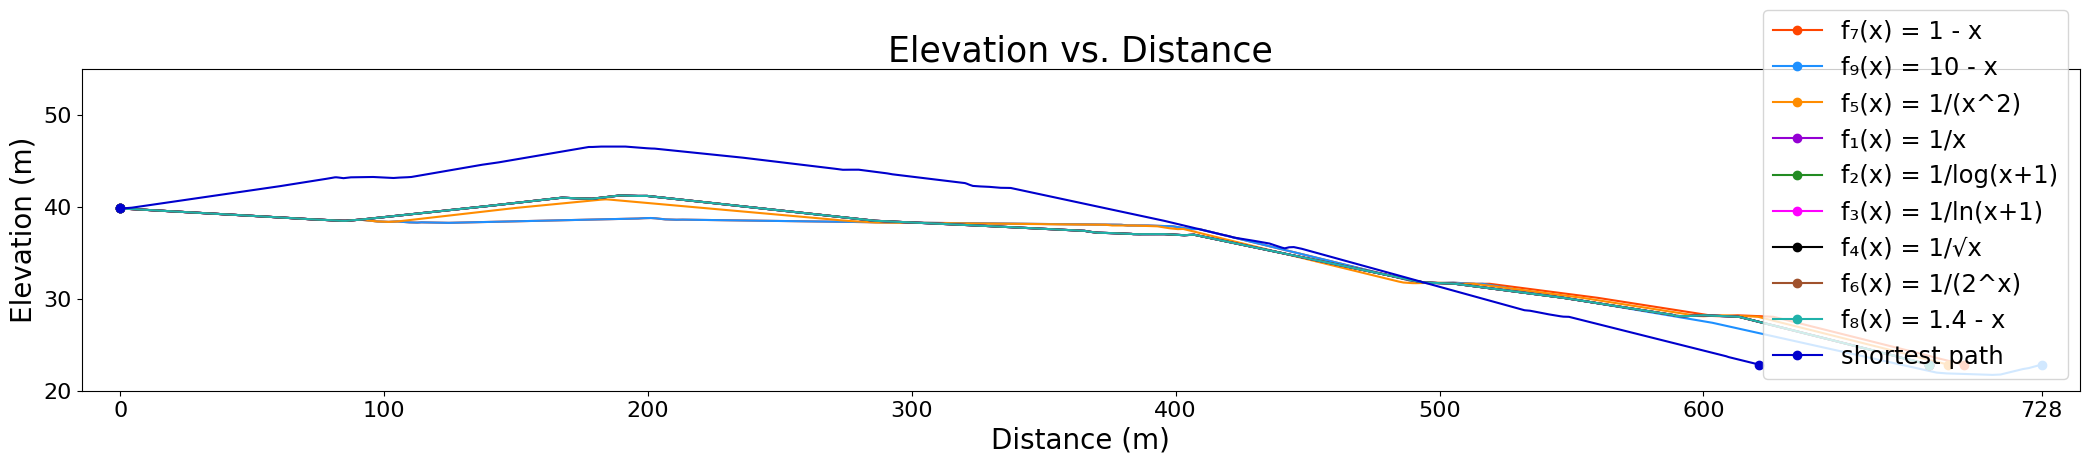

In [82]:
ranked_paths_df = pd.DataFrame(columns=[
    'sample_id', 'path_type', 'type_id', 'length', 'travel_time', 'score',
    'walkability_rank', 'dist_rank', 'slope_elevation_penalty',
    'max_subsegment_slope', 'elevation_change', 'elevation_penalty', 'mean_slope_elevation',
    'elevation_rank', 'alpha', 'beta', 'gamma', 'minutes', 'neighborhood',
    'path'
])

# for each sample
for row_idx, row in routes_df.iterrows():
    shortest_time = 0
    sample_id = row['sample_id']
    origin_str = row['origin']
    destination_str = row['destination']
    neighborhood = row['neighborhood']
    minutes = row['minutes']
    
    # parse coords
    origin_lat, origin_lon = map(float, origin_str.split(','))
    origin_point = (origin_lat, origin_lon)
    destination_lat, destination_lon = map(float, destination_str.split(','))
    destination_point = (destination_lat, destination_lon)

    origin_node = ox.nearest_nodes(G_foot, origin_lon, origin_lat)
    destination_node = ox.nearest_nodes(G_foot, destination_lon, destination_lat)

    all_r = []

    # for each multiplier for later
    for a in range(len(alpha_mult)):
        for b in range(len(beta_mult)):
            for c in range(len(gamma_mult)):
                all_r = []
                shortest_time = 0

                # for each function / and slope function
                for j in range(num_fxns):
            
                    create_abc_cols(directed_edges, alphas, betas, gammas)
                    G, G_undir = build_graph(nodes, directed_edges, fxn_names[j])

                    # get k shortest paths
                    paths = list(ox.k_shortest_paths(G, origin_node, destination_node, k=1, weight='score'))

                    # loop over each path
                    for rank_id, path in enumerate(paths, start=1):
                        p_elevation, p_slope, p_combined, elevation_change, mean_slope = path_elevation_penalties(path)

                        if (fxn_names[j] != "shortest"):
                            all_r.append({
                                    'function': fxn_names[j],
                                    'equation': fxn_equations[j],
                                    'path': path,
                                    'alpha': alphas[j],
                                    'beta': betas,
                                    'gamma': gammas,
                                    'score': calculate_path_score(G, path),
                                    'length': calculate_path_length(G, path, 'score'),
                                    'time': calculate_path_travel_time(G, path),
                                    'walkability_rank': 0,
                                    'dist_rank': 0,
                                    'elevation_penalty_only': p_elevation, 
                                    'path_max_slope': p_slope, 
                                    'elevation_penalty': p_combined,
                                    'elevation_change': elevation_change,
                                    'mean_slope_elevation': mean_slope,
                                    'type_id': rank_id
                            })
                        else:
                            all_r.append({
                                    'function': fxn_names[j],
                                    'equation': fxn_equations[j],
                                    'path': path,
                                    'alpha': np.nan,
                                    'beta': betas,
                                    'gamma': gammas,
                                    'score': calculate_path_score(G, path),
                                    'length': calculate_path_length(G, path, 'score'),
                                    'time': calculate_path_travel_time(G, path),
                                    'walkability_rank': 0,
                                    'dist_rank': 0,
                                    'elevation_penalty_only': p_elevation, 
                                    'path_max_slope': p_slope, 
                                    'elevation_penalty': p_combined,
                                    'elevation_change': elevation_change,
                                    'mean_slope_elevation': mean_slope,
                                    'type_id': rank_id
                            })

                        # keep shortest time (only for the best length path)
                        if fxn_names[j] == 'length' and rank_id == 1:
                            shortest_time = all_r[-1]['time']
                    
                id_fxn = {'sample_id': sample_id, 'origin': origin_str, 'destination': destination_str}

                # rerank paths (still just across the all_r set)
                dist_r = sort_paths(G, all_r, 'dist')
                longest = dist_r[0]['length']
                score_r = sort_paths(G, all_r, 'score')
                elevation_r = sort_paths(G, all_r, 'elevation')

                top_dist = []
                top_score = []
                
                # plot maps/graphs
                image, color_info = plot_all_paths(G, all_r, origin_point, destination_point, sample_id)
                filepath = f"path_images/hyperparams_testing/112/{sample_id}_1005_f"
                elevation_graph(all_r, filepath, longest, color_info)
                image.save(f"path_images/hyperparams_testing/112/{sample_id}_1005_f.html")

                # make rows for df
                rows = []
                for pos, path in enumerate(all_r, start=1):
                    if path['dist_rank'] == 1:
                        top_dist.append(path['function'])
                    if path['walkability_rank'] == 1:
                        top_score.append(path['function'])
                    if path['elevation_rank'] == 1:
                        top_score.append(path['function'])

                    time_diff_min = path['time'] - shortest_time
                    rows.append({
                        'sample_id': sample_id, 
                        'path_type': path['function'], 
                        'type_id': path['type_id'],
                        'length': path['length'], 
                        'travel_time': path['time'], 
                        'score': path['score'], 
                        'walkability_rank': path['walkability_rank'], 
                        'dist_rank': path['dist_rank'], 
                        'slope_elevation_penalty': path['elevation_penalty'],
                        'elevation_rank': path['elevation_rank'],
                        'max_subsegment_slope': path['path_max_slope'],
                        'elevation_change': path['elevation_change'],
                        'elevation_penalty': path['elevation_penalty_only'],
                        'mean_slope_elevation': path['mean_slope_elevation'],
                        'alpha': path['alpha'], 
                        'beta': path['beta'], 
                        'gamma': path['gamma'], 
                        'minutes': minutes, 
                        'neighborhood': neighborhood,
                        'path': path['path']
                    })

                ranked_paths_df = pd.concat([ranked_paths_df, pd.DataFrame(rows)], ignore_index=True)


In [83]:
all_r_new = [
    {
        'function': 'linear1',
        'equation': 'f₇(x) = 1 - x',
        'path': [5321052687, 5321052640, 5321099791, 5321052684, 5321099788, 5321099787, 5321058686, 5321058689, 5321058685, 10711113645, 5321058684, 5321058683, 5321117610, 5321026259, 5321026253, 5321026260, 5317640505, 5317640506, 11884101126, 5317640508, 5317640509, 5317640498, 5317640518],
        'alpha': 2.8619486788640733,
        'beta': 0.03599196766066179,
        'gamma': [0.7681478999835533, 0.45658323840986814, 4.9806974387046274, 1.6645164035557813],
        'score': 0.7558975514773819,
        'length': 777.8313555323502,
        'time': 9.722905679208134,
        'walkability_rank': 2,
        'dist_rank': 9,
        'elevation_penalty_only': 0.902610778808608,
        'path_max_slope': 0.08502752841935238,
        'elevation_penalty': 0.13015806735978278,
        'elevation_change': 17.006408691406254,
        'mean_slope_elevation': 0.14651633602715627,
        'type_id': 1,
        'elevation_rank': 1
    },
    {
        'function': 'linear10',
        'equation': 'f₉(x) = 10 - x',
        'path': [5321052687, 5321052640, 5321099791, 5321052684, 5321099788, 5321099787, 5321058686, 5321058689, 5321058685, 10711113645, 5321058684, 5321058683, 5321117610, 5321026259, 5321026253, 5321026260, 5317640505, 5317640504, 5317640512, 10713304216, 5317641621, 5317640518],
        'alpha': 0.10695859488726189,
        'beta': 0.03599196766066179,
        'gamma': [0.7681478999835533, 0.45658323840986814, 4.9806974387046274, 1.6645164035557813],
        'score': 0.7367165057527593,
        'length': 813.3585570308167,
        'time': 10.166996325283211,
        'walkability_rank': 3,
        'dist_rank': 10,
        'elevation_penalty_only': 1.9255332946777592,
        'path_max_slope': 0.06830201152843171,
        'elevation_penalty': 0.16457867626231967,
        'elevation_change': 18.129661560058604,
        'mean_slope_elevation': 0.1546043971700397,
        'type_id': 1,
        'elevation_rank': 2
    },
    {
        'function': 'inverse_sqr',
        'equation': 'f₅(x) = 1/(x²)',
        'path': [5321052687, 5321052640, 5321099791, 5321052684, 5321099788, 5321052644, 5321052651, 5321052649, 5321058675, 5321058674, 5321058684, 5321058683, 5321117610, 5321026259, 5321026253, 5321026260, 5317640505, 5317640506, 11884101126, 5317640508, 5317640509, 5317640498, 5317640518],
        'alpha': 0.3902260879589754,
        'beta': 0.03599196766066179,
        'gamma': [0.7681478999835533, 0.45658323840986814, 4.9806974387046274, 1.6645164035557813],
        'score': 0.7697674454583485,
        'length': 771.623469103851,
        'time': 9.645306989232175,
        'walkability_rank': 1,
        'dist_rank': 8,
        'elevation_penalty_only': 2.7445907592773295,
        'path_max_slope': 0.08502752841935238,
        'elevation_penalty': 0.22225706638321885,
        'elevation_change': 17.98916244506835,
        'mean_slope_elevation': 0.16090668473985767,
        'type_id': 1,
        'elevation_rank': 3
    },
    {
        'function': 'inverse',
        'equation': 'f₁(x) = 1/x',
        'path': [5321052687, 5321052640, 5321099791, 5321052684, 5321052653, 5321052683, 5321052648, 5321015074, 5321015076, 10711113647, 5321020984, 5321020998, 5321020996, 5321020989, 5321026248, 5321026247, 5317640506, 11884101126, 5317640508, 5317640509, 5317640498, 5317640518],
        'alpha': 0.6342820592464096,
        'beta': 0.03599196766066179,
        'gamma': [0.7681478999835533, 0.45658323840986814, 4.9806974387046274, 1.6645164035557813],
        'score': 0.7270237146642473,
        'length': 765.7005478377325,
        'time': 9.571270368817931,
        'walkability_rank': 4,
        'dist_rank': 2,
        'elevation_penalty_only': 3.0400581359863317,
        'path_max_slope': 0.08502752841935238,
        'elevation_penalty': 0.23703043521866898,
        'elevation_change': 18.415927886962894,
        'mean_slope_elevation': 0.16577587574695643,
        'type_id': 1,
        'elevation_rank': 4
    },
    {
        'function': 'shortest',
        'equation': 'shortest path',
        'path': [5321052687, 5321052688, 5321052691, 5768929594, 5321006288, 5321052661, 10698802772, 10698802748, 5321006290, 5321006283, 5321006273, 5320888992, 10698802774, 5320888993, 5320897450, 5319775503, 5319775500, 10707035555, 5319767896, 5319768744, 5319768729, 5319768725, 10708025945, 5319768732, 5319768736, 5318135196, 5318135200, 5317640497, 5317640498, 5317640518],
        'alpha': None,
        'beta': 0.03599196766066179,
        'gamma': [0.7681478999835533, 0.45658323840986814, 4.9806974387046274, 1.6645164035557813],
        'score': 0.6986475746456544,
        'length': 728.1234377966939,
        'time': 9.10155582976314,
        'walkability_rank': 10,
        'dist_rank': 1,
        'elevation_penalty_only': 7.083560943603487,
        'path_max_slope': 0.09928234469713329,
        'elevation_penalty': 0.4534603918773077,
        'elevation_change': 23.74111938476562,
        'mean_slope_elevation': 0.19436542391501077,
        'type_id': 1,
        'elevation_rank': 10
    }
]


In [84]:
elevation_graph(all_r_new, "test_pls.png", longest)

TypeError: elevation_graph() missing 1 required positional argument: 'color_info'

In [ ]:
image = plot_all_paths(G, all_r_new, origin_point, destination_point, sample_id)
image.save(f"path_images/hyperparams_testing/112/{sample_id}_1005_f.html")

In [ ]:
import os
path = "samples_final.csv"
exists_with_data = os.path.isfile(path) and os.path.getsize(path) > 0
ranked_paths_df.to_csv(path, mode="a", index=False, header=not exists_with_data)